# Chapter 2 - Supervised Learning

This notebook contains code reproductions, theoretical explanations, and discussions based on Chapter 2 of *Introduction to Machine Learning with Python: A Guide for Data Scientists* by Andreas C. Müller and Sarah Guido.

## Chapter Summary

This chapter introduces supervised learning, one of the most widely used approaches in machine learning. In supervised learning, models learn from labeled examples and use that knowledge to make predictions on unseen data.

The chapter covers both classification and regression problems and presents several commonly used algorithms, including k-Nearest Neighbors, Linear Models, Decision Trees, Random Forests, Gradient Boosting, Support Vector Machines, and Neural Networks.

The strengths, limitations, and practical applications of each algorithm are also discussed.

# Supervised Learning

Supervised learning is a machine learning approach where a model learns from labeled training data. Each example contains input features and a known target value.

The goal is to learn a relationship between inputs and outputs so that the model can make accurate predictions for new data.

Supervised learning problems are generally divided into two categories:

- Classification
- Regression

## Classification

Classification is used when the target variable belongs to a predefined category.

Examples:

- Spam or not spam
- Fraud or non-fraud
- Benign or malignant tumor

The output of a classification model is a class label.

## Regression

Regression is used when the target variable is continuous.

Examples:

- House price prediction
- Sales forecasting
- Temperature prediction

The output of a regression model is a numerical value.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mglearn

from sklearn.model_selection import train_test_split

%matplotlib inline

# k-Nearest Neighbors Classification

The k-Nearest Neighbors (KNN) algorithm classifies new data points based on the labels of nearby training examples.

The value of k determines how many neighbors are considered when making a prediction.

A small value of k may lead to overfitting, while a large value may oversimplify the decision boundary.

In [5]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=66
)

In [6]:
from sklearn.neighbors import KNeighborsClassifier

training_accuracy = []
test_accuracy = []

neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)

    training_accuracy.append(
        clf.score(X_train, y_train)
    )

    test_accuracy.append(
        clf.score(X_test, y_test)
    )

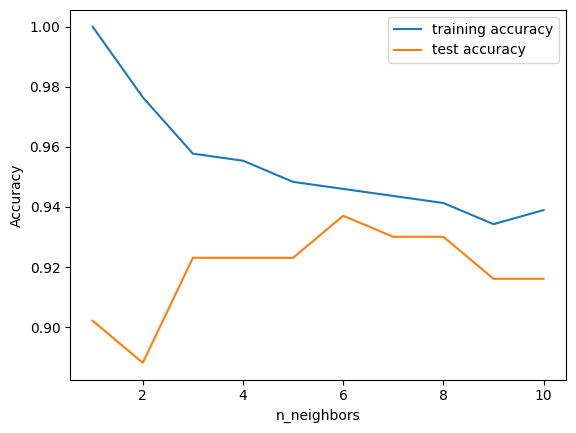

In [7]:
plt.plot(
    neighbors_settings,
    training_accuracy,
    label="training accuracy"
)

plt.plot(
    neighbors_settings,
    test_accuracy,
    label="test accuracy"
)

plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

plt.show()

### Discussion

The graph shows how model performance changes as the number of neighbors increases.

When k is very small, the model may memorize the training data and overfit. As k increases, the model becomes more stable and may generalize better to unseen data.

Selecting an appropriate value of k is important for achieving good performance.

# k-Nearest Neighbors Regression

The k-Nearest Neighbors algorithm can also be used for regression tasks. Instead of predicting a class label, the model predicts a numerical value based on the average target values of nearby training examples.

The choice of k affects how smooth the resulting predictions become.

In [9]:
from sklearn.neighbors import KNeighborsRegressor

X, y = mglearn.datasets.make_wave(n_samples=40)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0
)

In [10]:
reg = KNeighborsRegressor(n_neighbors=3)

reg.fit(X_train, y_train)

print("Test set predictions:\n{}".format(
    reg.predict(X_test)
))

Test set predictions:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [11]:
print("Test set R^2 score: {:.2f}".format(
    reg.score(X_test, y_test)
))

Test set R^2 score: 0.83


### Discussion

KNN regression predicts continuous values by averaging the outputs of neighboring training samples.

The R² score measures how well the model explains the variation in the target variable. A higher score indicates better predictive performance.

# Linear Regression

Linear Regression is one of the simplest machine learning algorithms for regression problems.

The model assumes a linear relationship between input features and the target variable. Predictions are generated by combining feature values with learned coefficients.

In [12]:
from sklearn.linear_model import LinearRegression

X, y = mglearn.datasets.make_wave(n_samples=60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [13]:
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))

lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746


In [14]:
print("Training set score: {:.2f}".format(
    lr.score(X_train, y_train)
))

print("Test set score: {:.2f}".format(
    lr.score(X_test, y_test)
))

Training set score: 0.67
Test set score: 0.66


### Discussion

Linear Regression learns coefficients that describe the relationship between input features and the target variable.

The model is simple, fast, and easy to interpret. However, its performance may decrease when the relationship between variables is highly non-linear.

# Ridge Regression

Ridge Regression is an extension of Linear Regression that includes regularization.

Regularization helps prevent overfitting by reducing the magnitude of model coefficients. This often improves generalization on unseen data.

In [15]:
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(X_train, y_train)

Ridge()

In [16]:
print("Training set score: {:.2f}".format(
    ridge.score(X_train, y_train)
))

print("Test set score: {:.2f}".format(
    ridge.score(X_test, y_test)
))

Training set score: 0.67
Test set score: 0.66


### Discussion

Compared to standard Linear Regression, Ridge Regression introduces a penalty that discourages large coefficients.

This often leads to more stable models and better performance on unseen data.

# Lasso Regression

Lasso Regression is another regularized linear model.

Unlike Ridge Regression, Lasso can reduce some coefficients to exactly zero, which effectively performs feature selection.

In [17]:
from sklearn.linear_model import Lasso

lasso = Lasso()

lasso.fit(X_train, y_train)

Lasso()

In [18]:
print("Training set score: {:.2f}".format(
    lasso.score(X_train, y_train)
))

print("Test set score: {:.2f}".format(
    lasso.score(X_test, y_test)
))

Training set score: 0.29
Test set score: 0.24


In [19]:
print("Number of features used:",
      np.sum(lasso.coef_ != 0))

Number of features used: 1


### Discussion

Lasso not only reduces overfitting but also simplifies models by selecting only the most important features.

This property makes Lasso useful when working with datasets containing many variables.

In [21]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=42
)

# Logistic Regression

Despite its name, Logistic Regression is primarily used for classification tasks.

The algorithm estimates the probability that an observation belongs to a particular class. It is widely used because it is simple, efficient, and often performs well on many classification problems.

In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=10000)

logreg.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [23]:
print("Training set score: {:.3f}".format(
    logreg.score(X_train, y_train)
))

print("Test set score: {:.3f}".format(
    logreg.score(X_test, y_test)
))

Training set score: 0.958
Test set score: 0.958


### Discussion

Logistic Regression creates a linear decision boundary between classes. Although simple, it often provides strong performance and serves as a useful baseline model for classification tasks.

# Decision Trees

Decision Trees split data into smaller groups using a series of decision rules.

Each split is selected to improve the separation between classes. The resulting structure resembles a tree, making the model easy to visualize and interpret.

In [24]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=0
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [25]:
print("Training set accuracy: {:.3f}".format(
    tree.score(X_train, y_train)
))

print("Test set accuracy: {:.3f}".format(
    tree.score(X_test, y_test)
))

Training set accuracy: 1.000
Test set accuracy: 0.937


### Discussion

Decision Trees can capture complex relationships within data. However, fully grown trees often overfit the training data, resulting in lower performance on unseen samples.

# Random Forest

Random Forest combines many decision trees into a single ensemble model.

Each tree is trained on a slightly different subset of the data. The final prediction is obtained by combining predictions from all trees, which generally improves accuracy and reduces overfitting.

In [26]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)

forest.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [27]:
print("Training set accuracy: {:.3f}".format(
    forest.score(X_train, y_train)
))

print("Test set accuracy: {:.3f}".format(
    forest.score(X_test, y_test)
))

Training set accuracy: 1.000
Test set accuracy: 0.958


### Discussion

Random Forest often performs better than a single Decision Tree because it reduces variance and improves generalization.

It is one of the most popular machine learning algorithms due to its strong performance and ease of use.

# Gradient Boosting

Gradient Boosting builds trees sequentially. Each new tree attempts to correct errors made by previous trees.

This approach can achieve high predictive performance but usually requires careful parameter tuning.

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gbrt = GradientBoostingClassifier(
    random_state=0
)

gbrt.fit(X_train, y_train)

GradientBoostingClassifier(random_state=0)

In [29]:
print("Training set accuracy: {:.3f}".format(
    gbrt.score(X_train, y_train)
))

print("Test set accuracy: {:.3f}".format(
    gbrt.score(X_test, y_test)
))

Training set accuracy: 1.000
Test set accuracy: 0.958


### Discussion

Gradient Boosting focuses on correcting previous mistakes, allowing it to build highly accurate models.

However, if not properly tuned, the model may overfit the training data.

# Support Vector Machines (SVM)

Support Vector Machines are powerful supervised learning algorithms used for both classification and regression.

The main idea is to find a decision boundary that maximizes the margin between different classes. A larger margin often leads to better generalization on unseen data.

SVMs can also use kernel functions to handle non-linear relationships.

In [30]:
from sklearn.svm import SVC

svc = SVC()

svc.fit(X_train, y_train)

SVC()

In [31]:
print("Training set accuracy: {:.3f}".format(
    svc.score(X_train, y_train)
))

print("Test set accuracy: {:.3f}".format(
    svc.score(X_test, y_test)
))

Training set accuracy: 0.918
Test set accuracy: 0.923


### Discussion

Support Vector Machines can achieve high accuracy, especially on complex datasets. However, they may require feature scaling and parameter tuning to obtain the best results.

Compared to simpler models, SVMs can be computationally expensive on large datasets.

# Neural Networks

Neural Networks are inspired by the structure of the human brain. They consist of interconnected layers of neurons that learn complex patterns from data.

In this chapter, a Multi-Layer Perceptron (MLP) is used as a basic neural network model for classification.

In [32]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

MLPClassifier(max_iter=1000, random_state=42)

In [33]:
print("Training set accuracy: {:.3f}".format(
    mlp.score(X_train, y_train)
))

print("Test set accuracy: {:.3f}".format(
    mlp.score(X_test, y_test)
))

Training set accuracy: 0.939
Test set accuracy: 0.916


### Discussion

Neural Networks can learn highly complex relationships and are widely used in modern machine learning applications.

Their flexibility makes them powerful, but they often require more data, computational resources, and parameter tuning compared to traditional machine learning algorithms.

# Model Comparison

Different algorithms have different strengths and weaknesses.

- KNN is simple and easy to understand.
- Linear models are fast and interpretable.
- Decision Trees are intuitive but may overfit.
- Random Forests improve stability by combining many trees.
- Gradient Boosting often achieves strong predictive performance.
- SVMs are powerful for complex classification tasks.
- Neural Networks can model highly complex patterns.

Choosing the best algorithm depends on the dataset, computational resources, and project requirements.

# Conclusion

This chapter explored several supervised learning algorithms used for classification and regression problems.

The experiments demonstrated how different models learn from labeled data and how their performance can vary depending on the characteristics of the dataset.

Algorithms such as KNN, Linear Regression, Logistic Regression, Decision Trees, Random Forests, Gradient Boosting, SVMs, and Neural Networks each offer unique advantages. Understanding these differences is important when selecting an appropriate model for a machine learning task.

The concepts introduced in this chapter provide a foundation for more advanced machine learning techniques discussed in later chapters.